In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as feature
import scipy


In [2]:
exp_list = ['flat10','flat10-zec','flat10-cdr']

models_list = ['ACCESS-ESM1-5',
'CESM2',
#'CNRM-ESM2-1',
'GFDL-ESM4',
#'GISS_E2.1',
'HadCM3LC-Bris',
'MPI-ESM1-2-LR',
#'NorESM2-LM',
'UKESM1.2',
'MIROC-ES2L']

nmodels = len(models_list)

dashpattern_list = ['-',':','--','-.',(0, (1, 10)),(5, (10, 3)),(0, (3, 10, 1, 10)),(0, (3, 5, 1, 5, 1, 5))]


In [3]:
def savgol_filter(array, window, order=2):
        smooth_array = array.copy()
        smooth_array[:] = scipy.signal.savgol_filter(array, window, order)
        return(smooth_array)

In [4]:
tas_ts_datarray = xr.open_dataset('tas_globalmean_timeseries_flat10mip.nc')

precip_ts_datarray = xr.open_dataset('precip_globalmean_timeseries_flat10mip.nc')

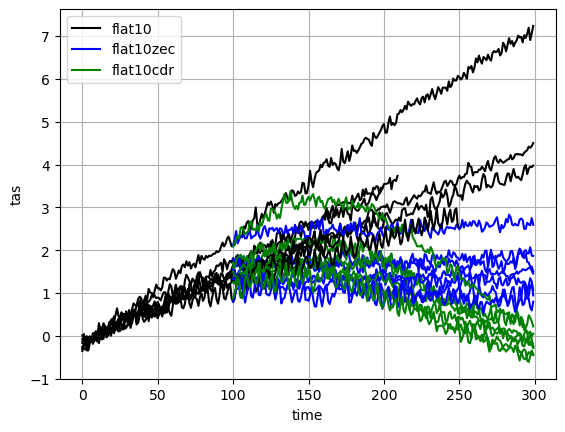

In [5]:
t_anom = tas_ts_datarray['tas'] - tas_ts_datarray['tas'] .isel(exp=0).isel(time=slice(0,20)).mean(dim='time')

#, linestyle=dashpattern_list[i], label=model)

for i, model in enumerate(models_list):
    if i == 0:
        annotation_flat10 = 'flat10'
        annotation_flat10zec = 'flat10zec'
        annotation_flat10cdr = 'flat10cdr'
    else:
        annotation_flat10 = None
        annotation_flat10zec = None
        annotation_flat10cdr = None
    t_anom.isel(exp=0).isel(model=i).plot(x='time', c='black', label=annotation_flat10)
    t_anom.isel(exp=1).isel(model=i).plot(x='time', c='blue', label=annotation_flat10zec)
    t_anom.isel(exp=2).isel(model=i).plot(x='time', c='green', label=annotation_flat10cdr)
plt.legend()
plt.title('')
plt.grid()


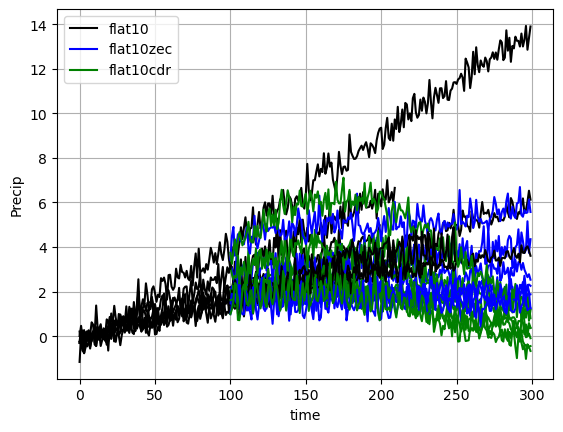

In [6]:
#p_percentchange = precip_ts_datarray['Precip'] / precip_ts_datarray['Precip'].isel(exp=0).isel(time=slice(0,20)).mean(dim='time')
p_percentchange = 100.*(precip_ts_datarray['Precip'] / precip_ts_datarray['Precip'].isel(exp=0).isel(time=slice(0,20)).mean(dim='time') - 1.)

for i in range(nmodels):
    if i == 0:
        annotation_flat10 = 'flat10'
        annotation_flat10zec = 'flat10zec'
        annotation_flat10cdr = 'flat10cdr'
    else:
        annotation_flat10 = None
        annotation_flat10zec = None
        annotation_flat10cdr = None
    p_percentchange.isel(exp=0).isel(model=i).plot(x='time', c='black', label=annotation_flat10)
    p_percentchange.isel(exp=1).isel(model=i).plot(x='time', c='blue', label=annotation_flat10zec)
    p_percentchange.isel(exp=2).isel(model=i).plot(x='time', c='green', label=annotation_flat10cdr)
    
plt.legend()
plt.title('')
plt.grid()


In [7]:
t_anom[0:100,1,:] = t_anom[0:100,0,:]
t_anom[0:100,2,:] = t_anom[0:100,0,:]

p_percentchange[0:100,1,:] = p_percentchange[0:100,0,:]
p_percentchange[0:100,2,:] = p_percentchange[0:100,0,:]

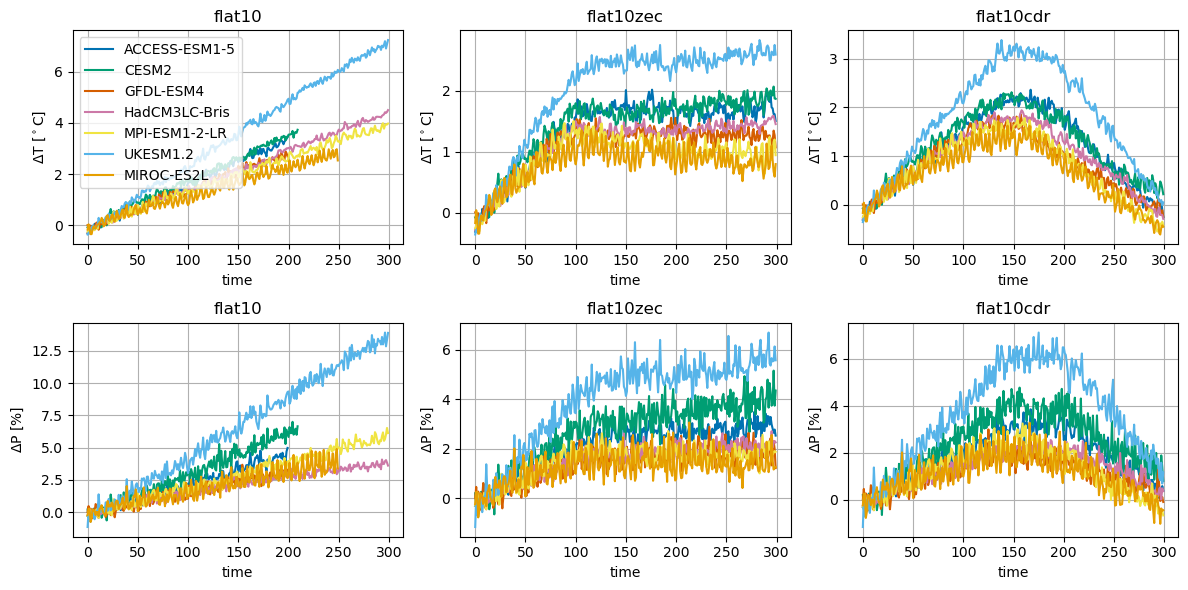

In [8]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 6))

filter_window = 15
axs_flat = axs.flatten()

color_list_models = ['#0072B2', '#009E73', '#D55E00', '#CC79A7', '#F0E442', '#56B4E9', '#E69F00']

for i, model in enumerate(models_list):
    t_anom.isel(exp=0).isel(model=i).plot(x='time', c=color_list_models[i], label=model, ax=axs_flat[0])
    t_anom.isel(exp=1).isel(model=i).plot(x='time', c=color_list_models[i], ax=axs_flat[1])
    t_anom.isel(exp=2).isel(model=i).plot(x='time', c=color_list_models[i], ax=axs_flat[2])
    #
    p_percentchange.isel(exp=0).isel(model=i).plot(x='time', c=color_list_models[i], ax=axs_flat[3])
    p_percentchange.isel(exp=1).isel(model=i).plot(x='time', c=color_list_models[i], ax=axs_flat[4])
    p_percentchange.isel(exp=2).isel(model=i).plot(x='time', c=color_list_models[i], ax=axs_flat[5])
    
axs_flat[0].legend()

axs_flat[0].set_title('flat10')
axs_flat[1].set_title('flat10zec')
axs_flat[2].set_title('flat10cdr')
axs_flat[3].set_title('flat10')
axs_flat[4].set_title('flat10zec')
axs_flat[5].set_title('flat10cdr')

axs_flat[0].set_ylabel('$\Delta$T [$^\circ$C]')
axs_flat[1].set_ylabel('$\Delta$T [$^\circ$C]')
axs_flat[2].set_ylabel('$\Delta$T [$^\circ$C]')
axs_flat[3].set_ylabel('$\Delta$P [%]')
axs_flat[4].set_ylabel('$\Delta$P [%]')
axs_flat[5].set_ylabel('$\Delta$P [%]')
for i in range(6):
    axs_flat[i].grid()

plt.tight_layout()
plt.show()

(-5.0, 5.0)

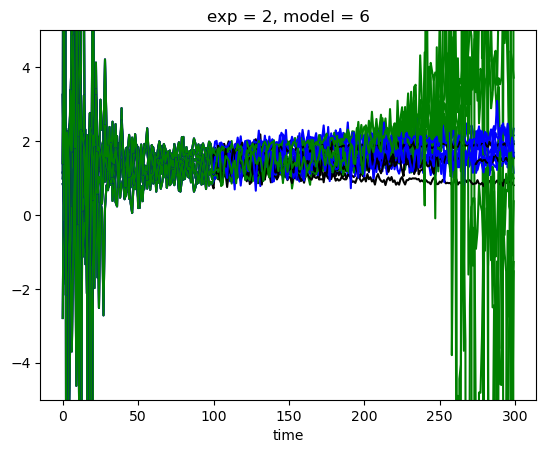

In [9]:
p_percentchange_perdegree = p_percentchange / t_anom

for i in range(nmodels):
    p_percentchange_perdegree.isel(exp=0).isel(model=i).plot(x='time', c='black')
    p_percentchange_perdegree.isel(exp=1).isel(model=i).plot(x='time', c='blue')
    p_percentchange_perdegree.isel(exp=2).isel(model=i).plot(x='time', c='green')

plt.ylim(-5,5)

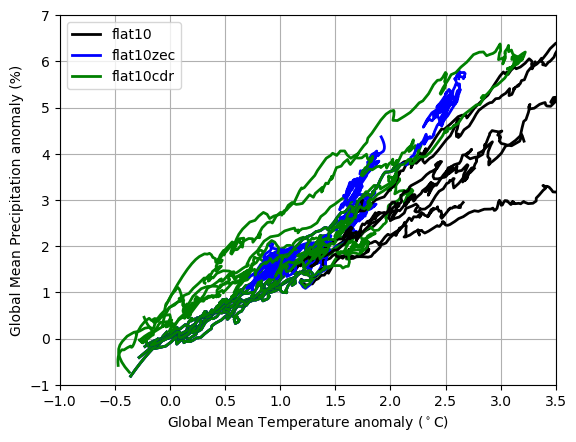

In [10]:
filter_window = 15

for i in range(nmodels):
    if i == 0:
        annotation_flat10 = 'flat10'
        annotation_flat10zec = 'flat10zec'
        annotation_flat10cdr = 'flat10cdr'
    else:
        annotation_flat10 = None
        annotation_flat10zec = None
        annotation_flat10cdr = None
    plt.plot(savgol_filter(t_anom.isel(exp=0).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=0).isel(model=i), filter_window), c='black', linewidth=2, label=annotation_flat10)
    plt.plot(savgol_filter(t_anom.isel(exp=1).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=1).isel(model=i), filter_window), c='blue', linewidth=2, label=annotation_flat10zec)
    plt.plot(savgol_filter(t_anom.isel(exp=2).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=2).isel(model=i), filter_window), c='green', linewidth=2, label=annotation_flat10cdr)
    
plt.xlabel('Global Mean Temperature anomaly ($^\circ$C)')
plt.ylabel('Global Mean Precipitation anomaly (%)')
plt.xlim(-1,3.5)
plt.ylim(-1,7)
plt.grid()
plt.legend()

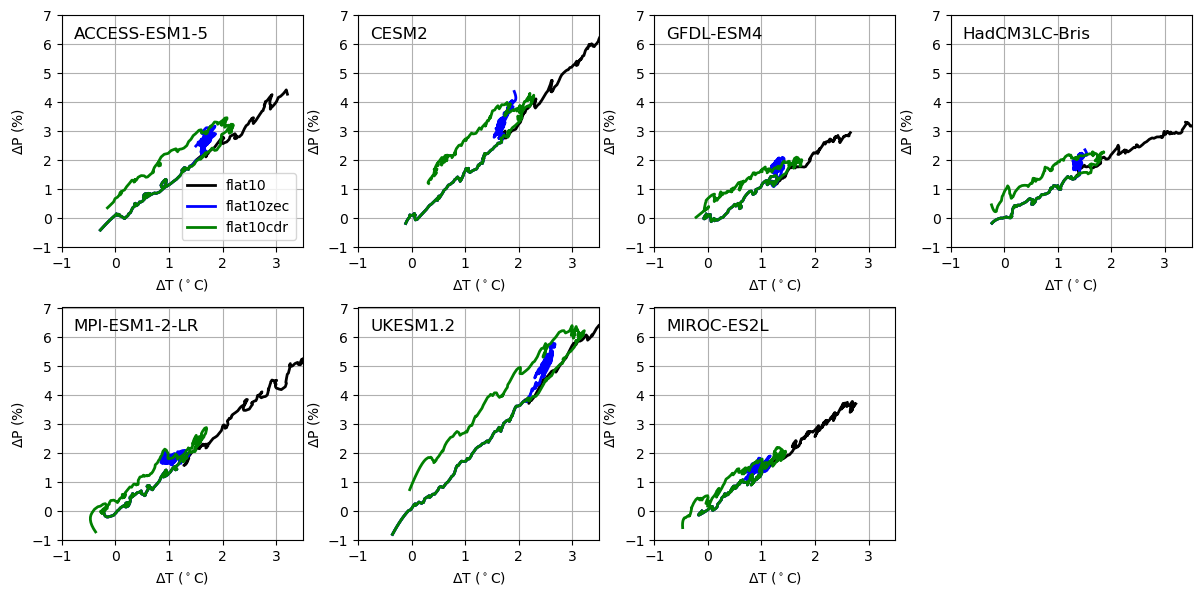

In [11]:
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(12, 6))

filter_window = 15
axs_flat = axs.flatten()

for i in range(nmodels):
    model = models_list[i]
    if i == 0:
        annotation_flat10 = 'flat10'
        annotation_flat10zec = 'flat10zec'
        annotation_flat10cdr = 'flat10cdr'
    else:
        annotation_flat10 = None
        annotation_flat10zec = None
        annotation_flat10cdr = None
    axs_flat[i].plot(savgol_filter(t_anom.isel(exp=0).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=0).isel(model=i), filter_window), c='black', linewidth=2, label=annotation_flat10)
    axs_flat[i].plot(savgol_filter(t_anom.isel(exp=1).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=1).isel(model=i), filter_window), c='blue', linewidth=2, label=annotation_flat10zec)
    axs_flat[i].plot(savgol_filter(t_anom.isel(exp=2).isel(model=i), filter_window), savgol_filter(p_percentchange.isel(exp=2).isel(model=i), filter_window), c='green', linewidth=2, label=annotation_flat10cdr)
    #
    axs_flat[i].set_xlabel('$\Delta$T ($^\circ$C)')
    axs_flat[i].set_ylabel('$\Delta$P (%)')
    axs_flat[i].set_xlim(-1,3.5)
    axs_flat[i].set_ylim(-1,7)
    axs_flat[i].grid()
    if i == 0:
        axs_flat[i].legend(loc='lower right')
    axs_flat[i].annotate(model, xy=(0.05, 0.9), xycoords='axes fraction', fontsize=12)

axs_flat[nmodels].axis('off')

plt.tight_layout()
plt.show()

In [12]:
time = np.arange(300)
flat10_emiss = np.ones(300)*10.

flat10zec_emiss = np.ones(300)*10.
flat10zec_emiss[100:] = 0.

flat10cdr_emiss = np.ones(300)*10.
flat10cdr_emiss[100:200] = 10. - np.arange(100)*0.2
flat10cdr_emiss[200:] = -10

flat10_cumemiss = flat10_emiss.cumsum()
flat10zec_cumemiss = flat10zec_emiss.cumsum()
flat10cdr_cumemiss = flat10cdr_emiss.cumsum()

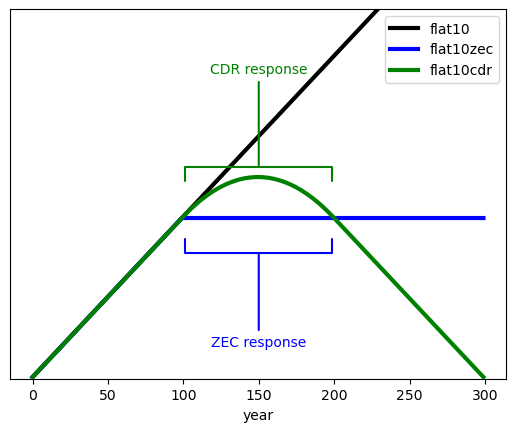

In [13]:
plt.plot(time, flat10_cumemiss, color='black', label='flat10', lw=3)
plt.plot(time, flat10zec_cumemiss, color='blue', label='flat10zec', lw=3)
plt.plot(time, flat10cdr_cumemiss, color='green', label='flat10cdr', lw=3)

plt.annotate('ZEC response', xy=(150, 800), xytext=(150, 200),
            arrowprops=dict(arrowstyle='-[, widthB=5.3, lengthB=1.0', lw=1.5, color='blue'), horizontalalignment='center',color='blue')
plt.annotate('CDR response', xy=(150, 1300), xytext=(150, 1900),
            arrowprops=dict(arrowstyle='-[, widthB=5.3, lengthB=1.0', lw=1.5, color='green'), horizontalalignment='center',color='green')
plt.ylim(0,2300)
plt.xlabel('year')
plt.legend()
plt.tick_params(left=False, labelleft=False)